Text Loader

In [3]:
from langchain_community.document_loaders import TextLoader
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv

load_dotenv()

model = ChatOpenAI()

prompt = PromptTemplate(
    template='Write a summary for the following poem - \n {poem}',
    input_variables=['poem']
)

parser = StrOutputParser()

loader = TextLoader('cricket.txt', encoding='utf-8')

docs = loader.load()

print(type(docs))

print(len(docs))

print(docs[0].page_content)

print(docs[0].metadata)

chain = prompt | model | parser

print(chain.invoke({'poem':docs[0].page_content}))



<class 'list'>
1
Beneath the sun or floodlight's gleam,

Cricket lives like a waking dream.

A field of green, a willowed sound,

Where legends rise and tales are found.

From dusty lanes where barefoot boys,

Chase every run with shrieks of joy,

To packed arenas roaring loud,

The game unites a global crowd.

A coin is tossed, the captains stare,

As tension thickens in the air.

Bat or bowl? A choice so bold,

A story new begins, retold.

The openers walk, calm yet brave,

Each stride a wave upon the wave.

They face the ball with narrowed eyes,

As silence grips the watching skies.

The bowler runs, a rhythmic beat,

Like thunder galloping on feet.

A leather flash, a wooden crack—

The ball takes flight, then tumbles back.

A flick through square, a drive through mid,

A lofted shot the fielder missed.

A single, double, sprint for three,

The crowd erupts in ecstasy.

But not for long—the trap is set,

The spinner loops, the pitch is wet.

A sudden turn, the bat’s deceived,

And 

CSV Loader

In [1]:
from langchain_community.document_loaders import CSVLoader

loader = CSVLoader(file_path='Social_Network_Ads.csv')

docs = loader.load()

print(len(docs))
print(docs[1])

400
page_content='User ID: 15810944
Gender: Male
Age: 35
EstimatedSalary: 20000
Purchased: 0' metadata={'source': 'Social_Network_Ads.csv', 'row': 1}


Directory Loader
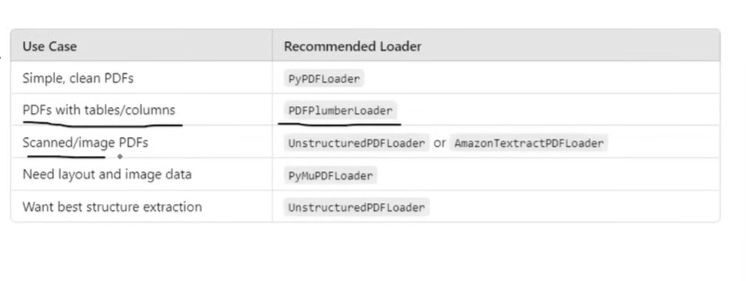
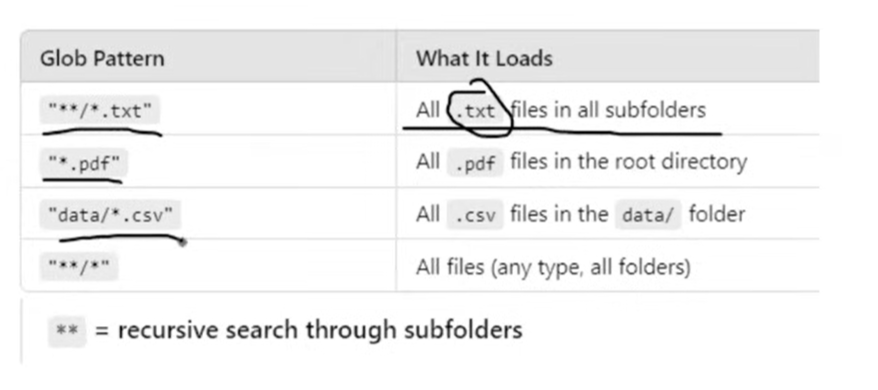
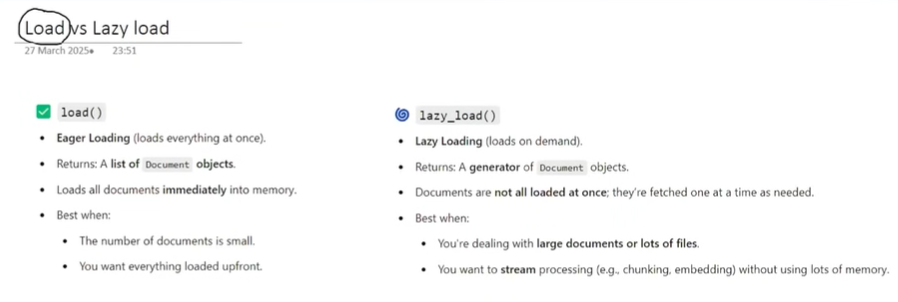

In [1]:
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader

loader = DirectoryLoader(
    path='books',
    glob='*.pdf',
    loader_cls=PyPDFLoader
)
# docs = loader.load() #slow
docs = loader.lazy_load() #

for document in docs:
    print(len(document.page_content))
    print(document.metadata)

5
{'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2015-03-24T13:14:02+05:30', 'moddate': '2015-03-25T17:33:08+05:30', 'trapped': '/False', 'source': 'books\\Building Machine Learning Systems with Python - Second Edition.pdf', 'total_pages': 326, 'page': 0, 'page_label': 'Cover'}
203
{'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2015-03-24T13:14:02+05:30', 'moddate': '2015-03-25T17:33:08+05:30', 'trapped': '/False', 'source': 'books\\Building Machine Learning Systems with Python - Second Edition.pdf', 'total_pages': 326, 'page': 1, 'page_label': 'FM1'}
1221
{'producer': 'Adobe PDF Library 10.0.1', 'creator': 'Adobe InDesign CS6 (Windows)', 'creationdate': '2015-03-24T13:14:02+05:30', 'moddate': '2015-03-25T17:33:08+05:30', 'trapped': '/False', 'source': 'books\\Building Machine Learning Systems with Python - Second Edition.pdf', 'total_pages': 326, 'page': 2, 'page_label': 'FM2'}


PDF Loader

In [5]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader('dl-curriculum.pdf')

docs = loader.load()

print(len(docs))

print(docs[0].page_content)
print("meta data : \n\n", docs[1].metadata)

23
CampusXDeepLearningCurriculum
A.ArtificialNeuralNetworkandhowtoimprovethem
1.BiologicalInspiration
● Understandingtheneuronstructure● Synapsesandsignaltransmission● Howbiologicalconceptstranslatetoartificialneurons
2.HistoryofNeuralNetworks
● Earlymodels(Perceptron)● BackpropagationandMLPs● The"AIWinter"andresurgenceofneuralnetworks● Emergenceofdeeplearning
3.PerceptronandMultilayerPerceptrons(MLP)
● Single-layerperceptronlimitations● XORproblemandtheneedforhiddenlayers● MLParchitecture
4. LayersandTheirFunctions
● InputLayer○ Acceptinginputdata● HiddenLayers○ Featureextraction● OutputLayer○ Producingfinalpredictions
5.ActivationFunctions
meta data : 

 {'producer': 'Skia/PDF m131 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': 'Deep Learning Curriculum', 'source': 'dl-curriculum.pdf', 'total_pages': 23, 'page': 1, 'page_label': '2'}


Webpage Data Loader

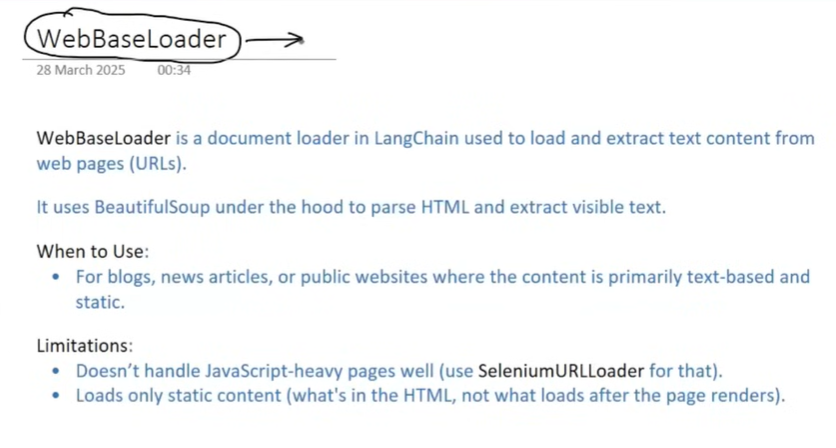

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from dotenv import load_dotenv

load_dotenv()

model = ChatOpenAI()

prompt = PromptTemplate(
    template='Answer the following question \n {question} from the following text - \n {text}',
    input_variables=['question','text']
)

parser = StrOutputParser()

url = 'https://www.flipkart.com/apple-macbook-air-m2-16-gb-256-gb-ssd-macos-sequoia-mc7x4hn-a/p/itmdc5308fa78421'
loader = WebBaseLoader(url)

docs = loader.load()


chain = prompt | model | parser

print(chain.invoke({'question':'What is the prodcut that we are talking about?', 'text':docs[0].page_content}))

USER_AGENT environment variable not set, consider setting it to identify your requests.


The product we are talking about is reCAPTCHA by Flipkart.


https://docs.langchain.com/oss/python/langchain/overview